# Step 4. Exploratory Data Analysis (EDA)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [23]:
clean_data = pd.read_csv('cleaned_data.csv')


## Phase 4: Exploratory Data Analysis (EDA)

### Step 7: Univariate Analysis

* Analyze individual variables.
* Study distributions.
* Identify trends.
* Detect anomalies.

### Step 8: Bivariate Analysis

* Analyze relationships between two variables.
* Compare categories.
* Measure associations.
* Identify influencing factors.

### Step 9: Multivariate Analysis

* Analyze interactions among multiple variables.
* Discover hidden patterns.
* Evaluate combined effects.
* Explore complex relationships.

### Step 10: Statistical Analysis

* Generate summary statistics.
* Measure variability.
* Analyze distributions.
* Identify correlations.
* Perform statistical validation where applicable.

---

In [24]:
clean_data.head(5)

,Unnamed: 0,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cleaned_reviews
0,0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[(4.0, 'A beautiful place to dine in.The inter..."
1,1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[(4.0, 'Had been here for dinner with family. ..."
2,2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[(3.0, ""Ambience is not that good enough and i..."
3,3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[(4.0, ""Great food and proper Karnataka style ..."
4,4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[(4.0, 'Very good restaurant in neighbourhood...."


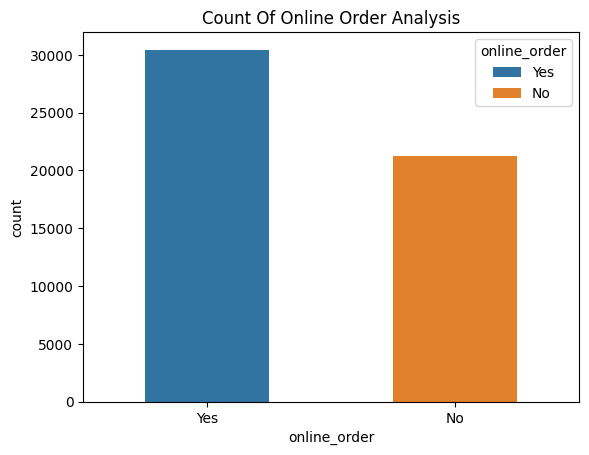

In [25]:
sns.countplot(data=clean_data,x='online_order',width=0.5,hue='online_order',legend=True)
plt.title('Count Of Online Order Analysis')
plt.show()

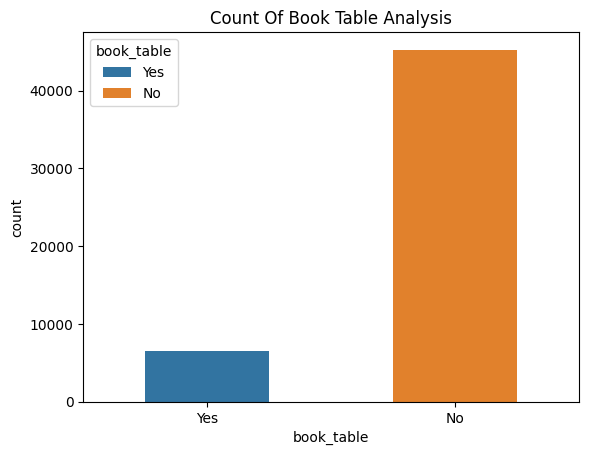

In [26]:
sns.countplot(data=clean_data,x='book_table',stat='count',width=0.5,hue='book_table',legend=True)
plt.title('Count Of Book Table Analysis')
plt.show()

In [27]:
clean_data['location'].describe()

count     51696
unique       93
top         BTM
freq       5124
Name: location, dtype: object

In [28]:
clean_data['location'].value_counts().head(10).index

Index(['BTM', 'HSR', 'Koramangala 5th Block', 'JP Nagar', 'Whitefield',
       'Indiranagar', 'Jayanagar', 'Marathahalli', 'Bannerghatta Road',
       'Bellandur'],
      dtype='object', name='location')

<Axes: xlabel='count', ylabel='location'>

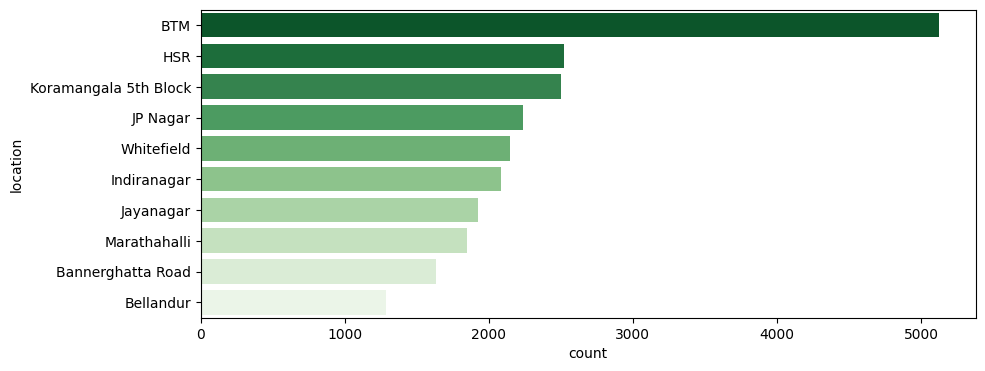

In [29]:
plt.figure(figsize=(10,4))
fliterd_data = clean_data['location'].value_counts().head(10).index
sns.countplot(
    data=clean_data, 
    y='location', 
    order=fliterd_data,
    palette='Greens_r'
)

In [30]:
clean_data['rest_type'].describe()

count           51717
unique             93
top       Quick Bites
freq            19359
Name: rest_type, dtype: object

<Axes: xlabel='count', ylabel='rest_type'>

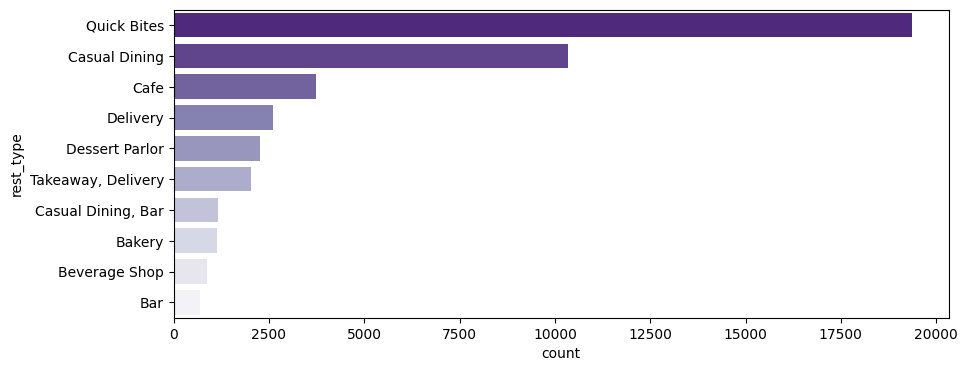

In [31]:
plt.figure(figsize=(10,4))
sns.countplot(
    data=clean_data,
    y='rest_type',
    order=clean_data['rest_type'].value_counts().head(10).index,
    palette='Purples_r'
)

In [32]:
clean_data['dish_liked'].describe()

count       51717
unique       5272
top       Unknown
freq        28078
Name: dish_liked, dtype: object

In [33]:
# 1. Filter out 'Unknown' rows completely for this analysis
valid_dishes = clean_data[clean_data['dish_liked'] != 'Unknown'].copy()
valid_dishes['dish_liked'].head()

0    Pasta, Lunch Buffet, Masala Papad, Paneer Laja...
1    Momos, Lunch Buffet, Chocolate Nirvana, Thai G...
2    Churros, Cannelloni, Minestrone Soup, Hot Choc...
3                                          Masala Dosa
4                                  Panipuri, Gol Gappe
Name: dish_liked, dtype: object

In [34]:
# 2. Convert to lowercase, split comma-separated dishes, and flatten the list
exploded_dishes = (
    valid_dishes['dish_liked']
    .str.lower()
    .str.split(',')
    .explode()
    .str.strip()
)


In [35]:
# 3. View the clean value counts
print(exploded_dishes.value_counts().head(10))

dish_liked
pasta         3409
burgers       3024
cocktails     2832
pizza         2737
biryani       2092
coffee        1994
mocktails     1887
sandwiches    1676
paratha       1566
noodles       1415
Name: count, dtype: int64


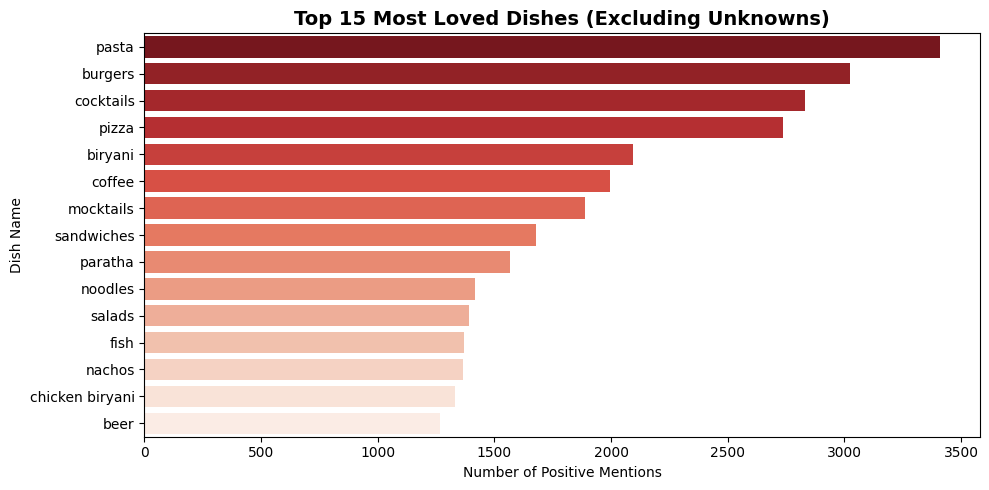

In [36]:
top_15_dishes = exploded_dishes.value_counts().head(15)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_15_dishes.values, 
    y=top_15_dishes.index, 
    palette='Reds_r'
)
plt.title('Top 15 Most Loved Dishes (Excluding Unknowns)', fontsize=14, weight='bold')
plt.xlabel('Number of Positive Mentions')
plt.ylabel('Dish Name')
plt.tight_layout()
plt.show()

In [37]:
clean_data['cuisines'].describe()

count            51717
unique            2723
top       North Indian
freq              2958
Name: cuisines, dtype: object

In [38]:
clean_data['cuisines'].iloc[25:100:20]

25                               Cafe, Bakery
45         North Indian, Continental, Italian
65    North Indian, Kebab, Chinese, Fast Food
85                           Bakery, Desserts
Name: cuisines, dtype: object

In [39]:
# 2. Convert to lowercase, split comma-separated cuisines, and flatten the list
exploded_cuisines = (
    valid_dishes['cuisines']
    .str.lower()
    .str.split(',')
    .explode()
    .str.strip()
)

In [40]:
exploded_cuisines.iloc[:200:25]

0     north indian
10            cafe
20            cafe
35         biryani
47           rolls
55        american
67         mexican
98     street food
Name: cuisines, dtype: object

In [41]:
# 3. View the clean value counts
print(exploded_cuisines.value_counts().head(10))

cuisines
north indian    10234
chinese          7581
continental      4334
cafe             3613
fast food        3273
south indian     2871
italian          2795
desserts         2707
biryani          2634
beverages        2350
Name: count, dtype: int64


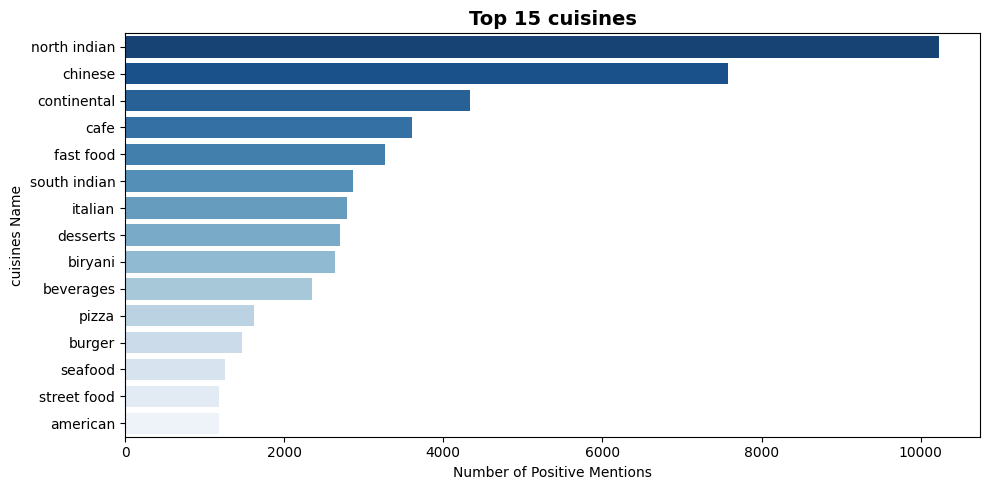

In [42]:
top_15_cuisines = exploded_cuisines.value_counts().head(15)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_15_cuisines.values, 
    y=top_15_cuisines.index, 
    palette='Blues_r'
)
plt.title('Top 15 cuisines', fontsize=14, weight='bold')
plt.xlabel('Number of Positive Mentions')
plt.ylabel('cuisines Name')
plt.tight_layout()
plt.show()

In [46]:
clean_data['menu_item'].describe()

count     51717
unique     9098
top          []
freq      39617
Name: menu_item, dtype: object